# GoEmotions 28-Class Emotion Classifier
**Model:** DistilBERT fine-tuned for single-label 28-class emotion classification  
**Dataset:** [google-research-datasets/go_emotions](https://huggingface.co/datasets/google-research-datasets/go_emotions)  
**Strategy:** Filter to single-label examples only, apply class weights to handle imbalance

---
### Pipeline
1. Install dependencies
2. Load & inspect GoEmotions
3. Filter single-label + clean text
4. Tokenise
5. Build model (DistilBERT + 28-class head)
6. Compute class weights
7. Train with WeightedTrainer
8. Evaluate (per-class F1 + confusion matrix)
9. Save & run inference

## 1. Install Dependencies

In [ ]:
!pip install -q transformers datasets evaluate scikit-learn accelerate

## 2. Imports & Config

In [ ]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import evaluate

# ── Config ──────────────────────────────────────────────────────────────────
MODEL_NAME   = "distilbert-base-uncased"
MAX_LENGTH   = 128
BATCH_SIZE   = 16
EPOCHS       = 5
LR           = 2e-5
OUTPUT_DIR   = "./go-emotions-28"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Load GoEmotions Dataset

In [ ]:
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
print(ds)

# Inspect the 28 label names
label_names = ds["train"].features["labels"].feature.names
print(f"\nNumber of labels: {len(label_names)}")
print("Labels:")
for i, name in enumerate(label_names):
    print(f"  {i:2d}: {name}")

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Number of labels: 28
Labels:
   0: admiration
   1: amusement
   2: anger
   3: annoyance
   4: approval
   5: caring
   6: confusion
   7: curiosity
   8: desire
   9: disappointment
  10: disapproval
  11: disgust
  12: embarrassment
  13: excitement
  14: fear
  15: gratitude
  16: grief
  17: joy
  18: love
  19: nervousness
  20: optimism
  21: pride
  22: realization
  23: relief
  24: remorse
  25: sadness
  26: surprise
  27: neutral


## 4. Filter Single-Label Examples

In [ ]:
print("Dataset size before filter:")
for split in ["train", "validation", "test"]:
    print(f"  {split}: {len(ds[split])}")

# Keep only examples with exactly one label
ds = ds.filter(lambda x: len(x["labels"]) == 1)

# Flatten list → scalar
ds = ds.map(lambda x: {"label": x["labels"][0]})

print("\nDataset size after single-label filter:")
for split in ["train", "validation", "test"]:
    print(f"  {split}: {len(ds[split])}")

Dataset size before filter:
  train: 43410
  validation: 5426
  test: 5427

Dataset size after single-label filter:
  train: 36308
  validation: 4548
  test: 4590


## 5. Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
    """Light cleaning for Reddit-sourced GoEmotions text."""
    text = re.sub(r'u/\w+', '', text)           # reddit usernames
    text = re.sub(r'r/\w+', '', text)           # subreddit names
    text = re.sub(r'http\S+|www\S+', '', text)  # URLs
    text = re.sub(r'&amp;', '&', text)          # HTML entities
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'\s+', ' ', text)            # collapse whitespace
    return text.strip()

ds = ds.map(lambda x: {"text": clean_text(x["text"])})

# Remove any examples that became empty after cleaning
ds = ds.filter(lambda x: len(x["text"]) > 0)

# Sanity check
print("Sample cleaned texts:")
for i in range(3):
    ex = ds["train"][i]
    print(f"  [{label_names[ex['label']]}] {ex['text']}")

Sample cleaned texts:
  [neutral] My favourite food is anything I didn't have to cook myself.
  [neutral] Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
  [anger] WHY THE FUCK IS BAYLESS ISOING


## 6. Class Distribution

Label                   Count      %
----------------------------------------
admiration               2710    7.5%
amusement                1652    4.6%
anger                    1025    2.8%
annoyance                1451    4.0%
approval                 1873    5.2%
caring                    649    1.8%
confusion                 858    2.4%
curiosity                1389    3.8%
desire                    389    1.1%
disappointment            709    2.0%
disapproval              1402    3.9%
disgust                   498    1.4%
embarrassment             203    0.6%
excitement                510    1.4%
fear                      430    1.2%
gratitude                1857    5.1%
grief                      39    0.1%
joy                       853    2.3%
love                     1427    3.9%
nervousness                85    0.2%
optimism                  861    2.4%
pride                      51    0.1%
realization               586    1.6%
relief                     88    0.2%
remorse   

/tmp/ipykernel_25282/2119620822.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_names, rotation=90)


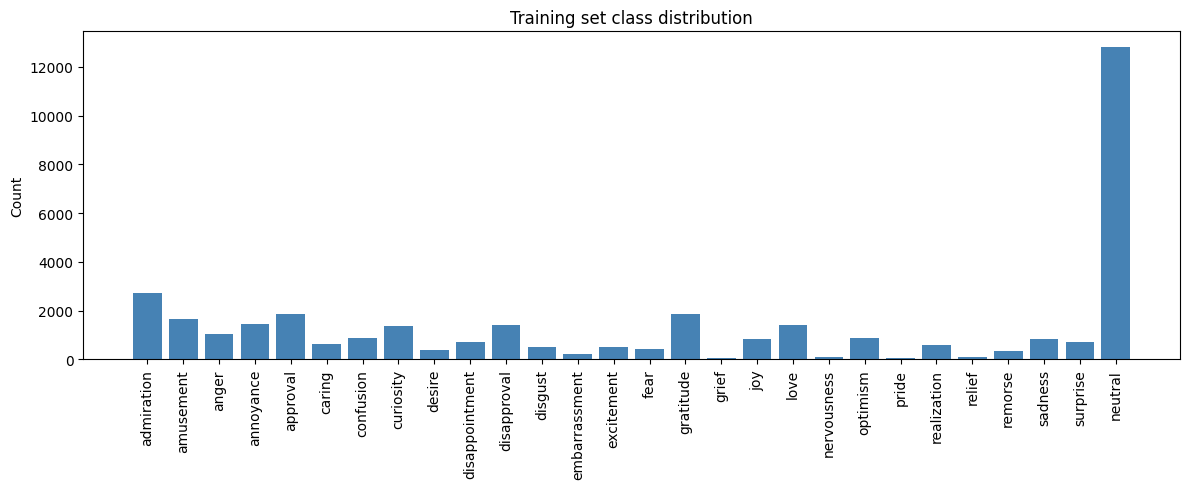

In [ ]:
counts = Counter(ds["train"]["label"])
total  = sum(counts.values())

print(f"{'Label':22s} {'Count':>6s}  {'%':>5s}")
print("-" * 40)
for idx in range(len(label_names)):
    c = counts.get(idx, 0)
    print(f"{label_names[idx]:22s} {c:6d}  {100*c/total:5.1f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(label_names, [counts.get(i, 0) for i in range(len(label_names))], color="steelblue")
ax.set_xticklabels(label_names, rotation=90)
ax.set_title("Training set class distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Tokenise

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized = ds.map(tokenize_fn, batched=True)


tokenized = tokenized.remove_columns("labels")          # drop the original multi-label list column
tokenized = tokenized.rename_column("label", "labels")  # rename scalar → labels

tokenized.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

train_ds = tokenized["train"]
val_ds   = tokenized["validation"]
test_ds  = tokenized["test"]

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Columns: {train_ds.column_names}")

Map:   0%|          | 0/4590 [00:00<?, ? examples/s]

Train: 36307  Val: 4548  Test: 4590
Columns: ['text', 'id', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


## 8. Model — DistilBERT + 28-Class Head

Architecture: `[CLS] token → 768-dim hidden → Dropout(0.1) → Linear(768 → 28) → softmax`

In [ ]:
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=28,
    id2label=id2label,
    label2id=label2id,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,975,004
Trainable parameters: 66,975,004


## 9. Class Weights

GoEmotions is heavily imbalanced across 28 classes. Class weights scale the loss so rare emotions are penalised more heavily when missed.

In [ ]:
train_labels = ds["train"]["label"]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(28),
    y=train_labels,
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print(weights_tensor)

# print(f"{'Label':22s} {'Weight':>8s}")
# print("-" * 32)
# for i, w in enumerate(weights_tensor):
#     print(f"{label_names[i]:22s} {w.item():8.3f}")


tensor([ 0.4785,  0.7849,  1.2651,  0.8936,  0.6923,  1.9980,  1.5113,  0.9335,
         3.3334,  1.8289,  0.9249,  2.6038,  6.3876,  2.5425,  3.0155,  0.6983,
        33.2482,  1.5201,  0.9087, 15.2550,  1.5060, 25.4251,  2.2128, 14.7350,
         3.6733,  1.5871,  1.8009,  0.1011])


In [ ]:
print(weights_tensor[-1])

tensor(0.1011)


In [ ]:
weights_tensor[-1] = 0.3

print(f"{'Label':22s} {'Weight':>8s}")
print("-" * 32)
for i, w in enumerate(weights_tensor):
    print(f"{label_names[i]:22s} {w.item():8.3f}")


Label                    Weight
--------------------------------
admiration                0.478
amusement                 0.785
anger                     1.265
annoyance                 0.894
approval                  0.692
caring                    1.998
confusion                 1.511
curiosity                 0.934
desire                    3.333
disappointment            1.829
disapproval               0.925
disgust                   2.604
embarrassment             6.388
excitement                2.543
fear                      3.016
gratitude                 0.698
grief                    33.248
joy                       1.520
love                      0.909
nervousness              15.255
optimism                  1.506
pride                    25.425
realization               2.213
relief                   14.735
remorse                   3.673
sadness                   1.587
surprise                  1.801
neutral                   0.300


## 10. Custom Weighted Trainer

In [ ]:
class WeightedTrainer(Trainer):
    """Trainer that applies class weights to CrossEntropyLoss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=weights_tensor.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

## 11. Metrics

In [ ]:
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return f1_metric.compute(
        predictions=preds,
        references=labels,
        average="weighted",
    )

## 12. Training Arguments & Train

In [ ]:
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1
1,1.615453,1.628231,0.552829
2,1.514949,1.493597,0.572863
3,1.141873,1.530679,0.577290
4,0.905174,1.588847,0.586701
5,0.758223,1.618068,0.583941


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=11350, training_loss=1.3572072991190502, metrics={'train_runtime': 818.7211, 'train_samples_per_second': 221.73, 'train_steps_per_second': 13.863, 'total_flos': 6014654844840960.0, 'train_loss': 1.3572072991190502, 'epoch': 5.0})

## 13. Training Loss Curve

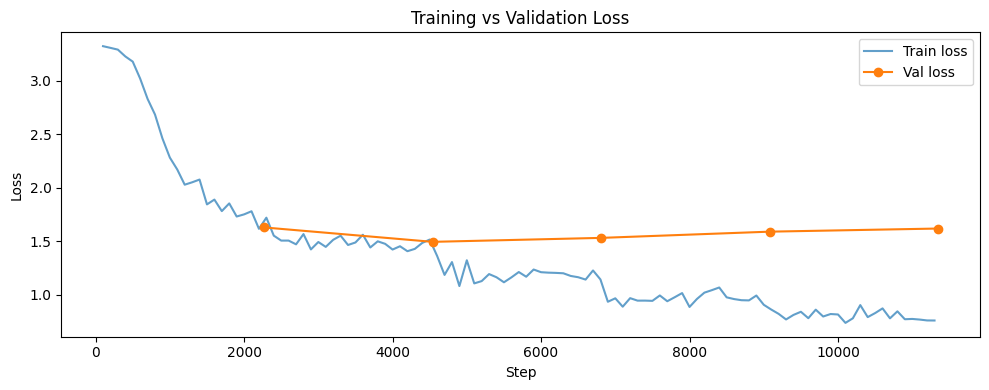

In [ ]:
log_history = trainer.state.log_history

train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="Train loss", alpha=0.7)
plt.plot(eval_steps,  eval_losses,  label="Val loss",   marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Evaluate on Test Set

In [ ]:
preds_out = trainer.predict(test_ds)
preds     = np.argmax(preds_out.predictions, axis=-1)
true      = preds_out.label_ids

print("=" * 60)
print("Per-class Classification Report")
print("=" * 60)
print(classification_report(
    true, preds,
    target_names=label_names,
    digits=3,
    zero_division=0,
))

Per-class Classification Report
                precision    recall  f1-score   support

    admiration      0.688     0.690     0.689       348
     amusement      0.753     0.903     0.822       186
         anger      0.426     0.595     0.497       131
     annoyance      0.305     0.186     0.231       194
      approval      0.399     0.411     0.405       236
        caring      0.305     0.500     0.379        86
     confusion      0.314     0.505     0.387        97
     curiosity      0.443     0.665     0.532       176
        desire      0.534     0.554     0.544        56
disappointment      0.338     0.307     0.321        88
   disapproval      0.370     0.467     0.413       195
       disgust      0.490     0.632     0.552        76
 embarrassment      0.438     0.609     0.509        23
    excitement      0.254     0.544     0.346        57
          fear      0.654     0.785     0.713        65
     gratitude      0.935     0.885     0.909       260
         grief 

## 15. Confusion Matrix

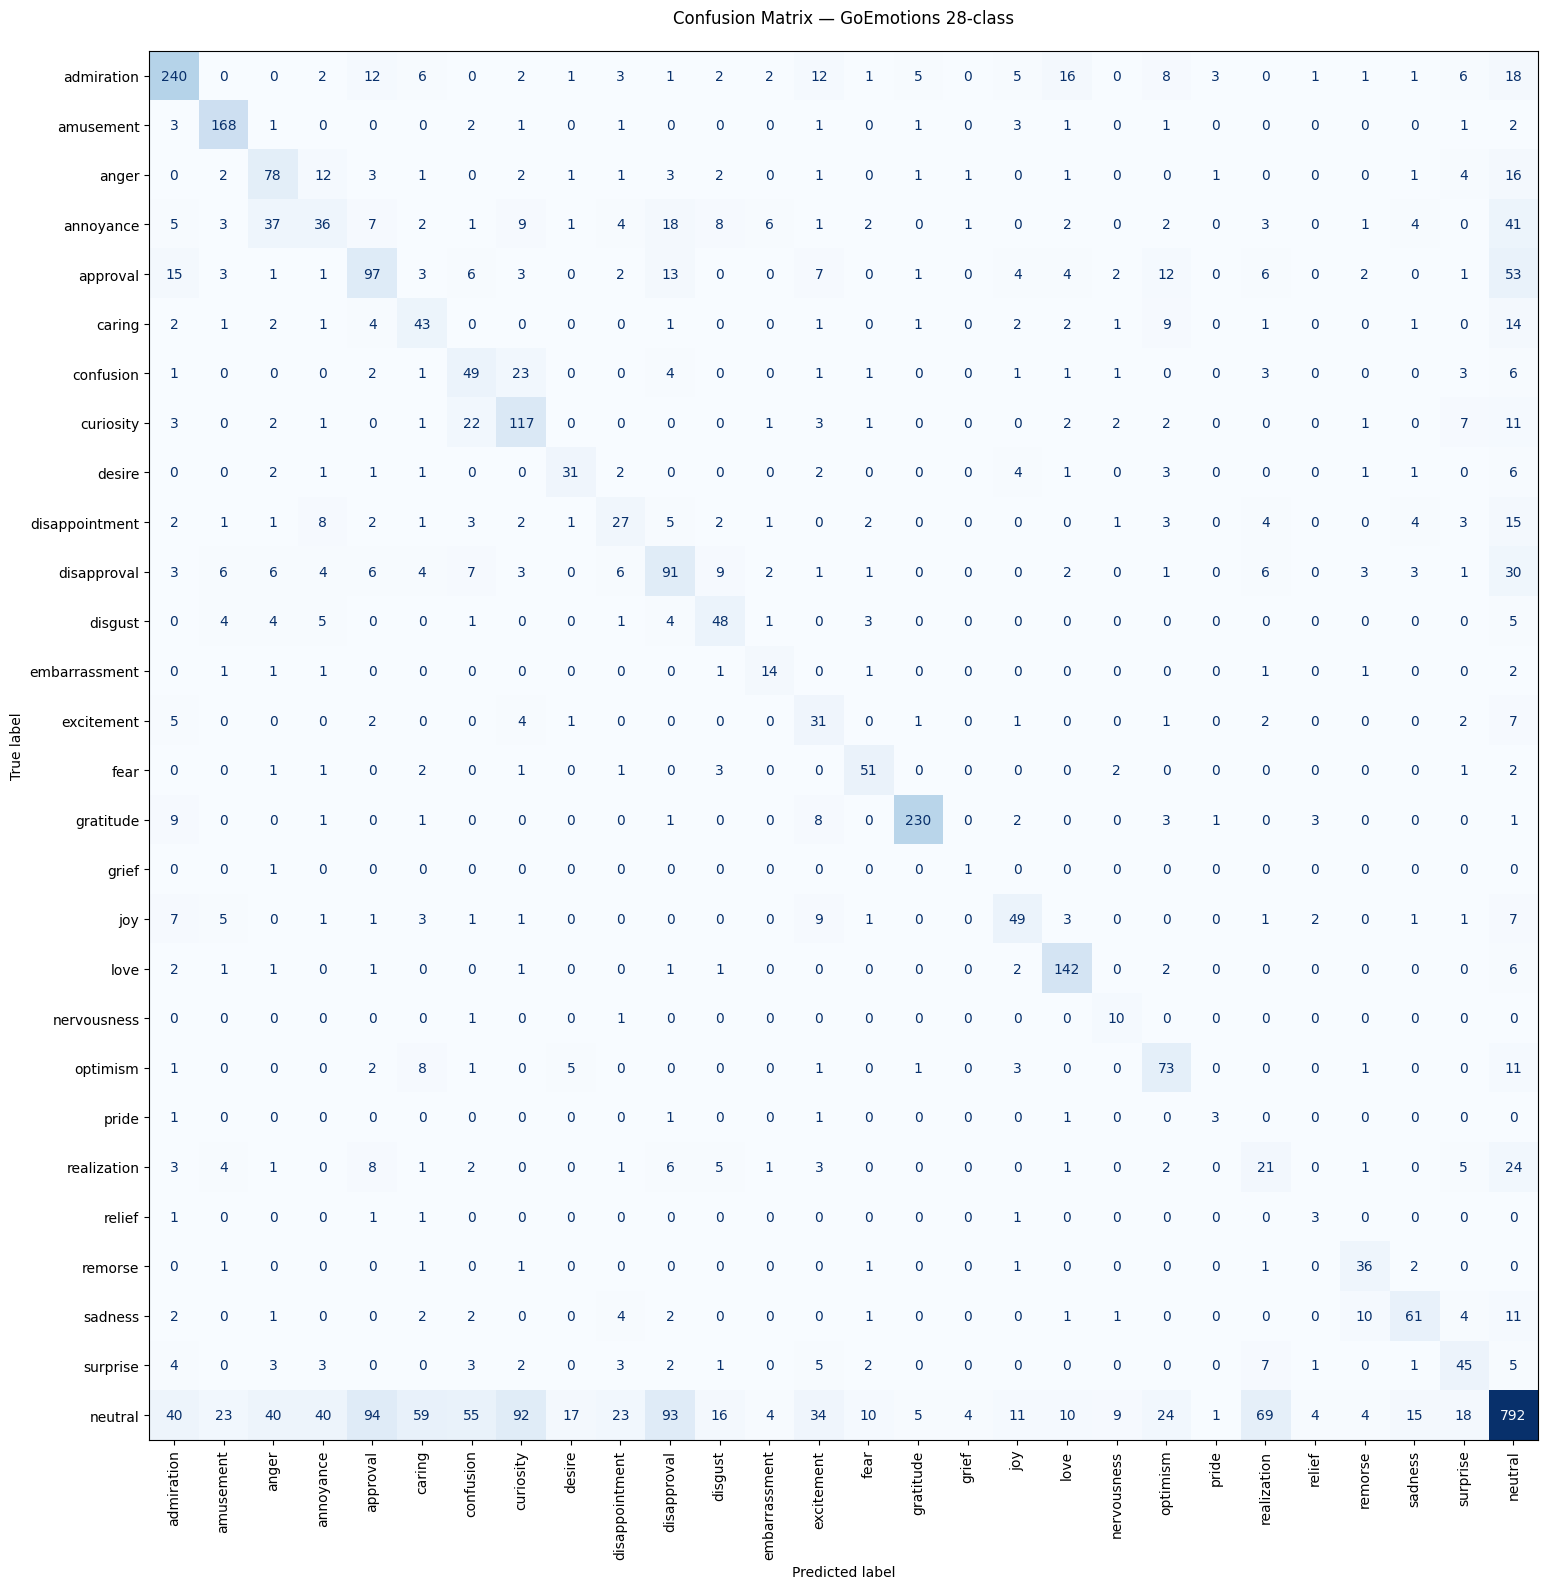

In [ ]:
fig, ax = plt.subplots(figsize=(18, 16))
ConfusionMatrixDisplay.from_predictions(
    true, preds,
    display_labels=label_names,
    ax=ax,
    xticks_rotation=90,
    colorbar=False,
    cmap="Blues",
)
ax.set_title("Confusion Matrix — GoEmotions 28-class", pad=20)
plt.tight_layout()
plt.show()

## 16. Per-Class F1 Bar Chart

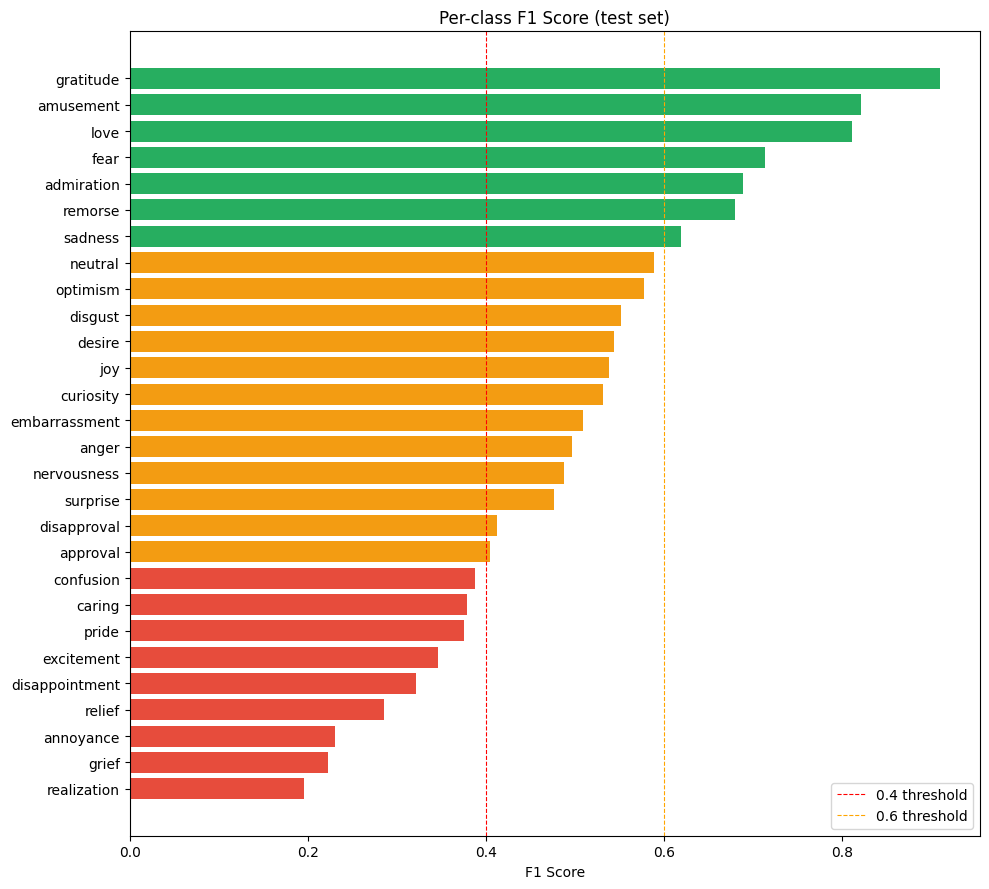

In [ ]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(true, preds, average=None, zero_division=0)
sorted_idx   = np.argsort(per_class_f1)

colors = ["#e74c3c" if f < 0.4 else "#f39c12" if f < 0.6 else "#27ae60"
          for f in per_class_f1[sorted_idx]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    [label_names[i] for i in sorted_idx],
    per_class_f1[sorted_idx],
    color=colors,
)
ax.axvline(0.4, color="red",    linestyle="--", linewidth=0.8, label="0.4 threshold")
ax.axvline(0.6, color="orange", linestyle="--", linewidth=0.8, label="0.6 threshold")

ax.set_xlabel("F1 Score")
ax.set_title("Per-class F1 Score (test set)")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Save Model

In [ ]:
SAVE_PATH = "./go-emotions-28-final"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved to {SAVE_PATH}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./go-emotions-28-final


## 18. Inference

In [ ]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
)

test_sentences = [
    "I can't believe how amazing this turned out!",
    "This is the worst day of my life.",
    "I'm not sure what to think about all of this.",
    "Thank you so much, you really saved me!",
    "I'm so scared about what's going to happen next.",
    "The meeting is scheduled for 3pm tomorrow.",
    "I miss them so much it physically hurts.",
]

print(f"{'Text':50s}  {'Label':15s}  Score")
print("-" * 80)
for sent in test_sentences:
    result = clf(sent)[0]
    print(f"{sent[:50]:50s}  {result['label']:15s}  {result['score']:.3f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text                                                Label            Score
--------------------------------------------------------------------------------
I can't believe how amazing this turned out!        excitement       0.441
This is the worst day of my life.                   disgust          0.613
I'm not sure what to think about all of this.       confusion        0.943
Thank you so much, you really saved me!             gratitude        0.992
I'm so scared about what's going to happen next.    fear             0.986
The meeting is scheduled for 3pm tomorrow.          neutral          0.523
I miss them so much it physically hurts.            sadness          0.957


## 19. Custom Inference Function (with top-3 predictions)

In [ ]:
import torch.nn.functional as F

# Reload for clean inference
infer_tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
infer_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
infer_model.eval()

def predict_emotions(text: str, top_k: int = 3):
    """Return top-k predicted emotions with confidence scores."""
    inputs = infer_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    with torch.no_grad():
        logits = infer_model(**inputs).logits

    probs     = F.softmax(logits, dim=-1).squeeze()
    top_probs, top_idx = probs.topk(top_k)

    return [
        {"label": label_names[idx.item()], "score": round(prob.item(), 4)}
        for prob, idx in zip(top_probs, top_idx)
    ]

# Try it out
text = "I can't believe they won! This is absolutely incredible!"
print(f"Input: {text}\n")
for pred in predict_emotions(text, top_k=3):
    bar = "█" * int(pred["score"] * 40)
    print(f"  {pred['label']:20s}  {pred['score']:.4f}  {bar}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input: I can't believe they won! This is absolutely incredible!

  admiration            0.8024  ████████████████████████████████
  excitement            0.1220  ████
  surprise              0.0313  █


In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive("go-emotions-28-final", "zip", "./go-emotions-28-final")

# Download to your machine
files.download("go-emotions-28-final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict(text, top_k=3):
  for pred in predict_emotions(text, top_k=top_k):
    bar = "█" * int(pred["score"] * 40)
    print(f"  {pred['label']:20s}  {pred['score']:.4f}  {bar}")

In [ ]:
predict("I would like to go to school")

predict("I am in love")

  desire                0.8985  ███████████████████████████████████
  neutral               0.0315  █
  optimism              0.0218  
  love                  0.9741  ██████████████████████████████████████
  neutral               0.0046  
  joy                   0.0036  


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# trainer.push_to_hub("Win02/go-emotions-28class-v2")
# tokenizer.push_to_hub("Win02/go-emotions-28class-v2")

# print("Model live at: https://huggingface.co/Win02/go-emotions-28class-v2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ions-28/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...ions-28/model.safetensors:   0%|          |  574kB /  268MB            

Model live at: https://huggingface.co/Win02/go-emotions-28class-v2


In [ ]:
# from transformers import DistilBertForSequenceClassification, AutoTokenizer

# trainer.save_model("./go-emotions-28-v2")
# tokenizer.save_pretrained("./go-emotions-28-v2")


# model = DistilBertForSequenceClassification.from_pretrained("./go-emotions-28-v2")
# tokenizer = AutoTokenizer.from_pretrained("./go-emotions-28-v2")

# model.push_to_hub("Win02/go-emotions-28class-v2")
# tokenizer.push_to_hub("Win02/go-emotions-28class-v2")

# print("Done: https://huggingface.co/Win02/go-emotions-28class-v2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...i781zg9/model.safetensors:  60%|#####9    |  160MB /  268MB            

Done: https://huggingface.co/Win02/go-emotions-28class-v2
